In [65]:
import pandas as pd

# Load the dataset correctly (update the path if needed)
data = pd.read_csv("NSCH_2021E_TOPICAL.csv")

# Check for missing values
print(data.isna().sum())

# Check data types of the variables
print(data.dtypes)

# Inspect the unique values to identify any non-numeric data
print(data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS', 'OVERWEIGHT']].head())


C:\Users\rm130166\AppData\Local\Temp\ipykernel_18088\2546139858.py:4: DtypeWarning: Columns (88,121,394,397,400,403,406,447) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("NSCH_2021E_TOPICAL.csv")


FIPSST       0
STRATUM      0
HHID         0
FORMTYPE     0
TOTKIDS_R    0
            ..
FPL_I5       0
FPL_I6       0
FWC          0
HEIGHT       0
WEIGHT       0
Length: 463, dtype: int64
FIPSST         int64
STRATUM       object
HHID           int64
FORMTYPE      object
TOTKIDS_R      int64
              ...   
FPL_I5         int64
FPL_I6         int64
FWC          float64
HEIGHT        object
WEIGHT        object
Length: 463, dtype: object
  K10Q11 K10Q40_R  SC_SEX  SC_RACE_R  TENURE  SC_AGE_YEARS OVERWEIGHT
0      1        1       1          4       1             2          2
1      2        3       1          7       2            12          2
2      1        2       1          1       1             8          2
3      1        1       2          1       1             2          2
4      2        1       2          1       3             5          2


In [66]:
print(data['OVERWEIGHT'].dtype)
print(data['OVERWEIGHT'].head())  # Inspect the first few rows

object
0    2
1    2
2    2
3    2
4    2
Name: OVERWEIGHT, dtype: object


In [67]:
print(data['OVERWEIGHT'].unique())


['2' '1' 'M']


In [68]:
data['OVERWEIGHT'] = pd.to_numeric(data['OVERWEIGHT'], errors='coerce')


In [69]:
print(data['OVERWEIGHT'].isnull().sum())  # Check for NaN values

# Option 1: Drop rows with NaN
data = data.dropna(subset=['OVERWEIGHT'])



234


In [70]:
print(data['OVERWEIGHT'].dtype)
print(data['OVERWEIGHT'].head())


float64
0    2.0
1    2.0
2    2.0
3    2.0
4    2.0
Name: OVERWEIGHT, dtype: float64


In [71]:
# Convert categorical overweight status (if 1=Yes, 2=No) to binary 0 and 1
data['OVERWEIGHT'] = data['OVERWEIGHT'].replace({1: 1, 2: 0})


In [72]:
# Check the unique values
print(data['OVERWEIGHT'].unique())


[0. 1.]


In [73]:
# Check data types of the independent and dependent variables
print(data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS', 'OVERWEIGHT']].dtypes)


K10Q11           object
K10Q40_R         object
SC_SEX            int64
SC_RACE_R         int64
TENURE            int64
SC_AGE_YEARS      int64
OVERWEIGHT      float64
dtype: object


In [74]:
# Convert object columns to numeric, coerce errors to NaN
data['K10Q11'] = pd.to_numeric(data['K10Q11'], errors='coerce')
data['K10Q40_R'] = pd.to_numeric(data['K10Q40_R'], errors='coerce')

# Check if there are any NaN values introduced during conversion
print(data[['K10Q11', 'K10Q40_R']].isna().sum())


K10Q11      1289
K10Q40_R    1543
dtype: int64


In [75]:
# Drop rows where either K10Q11 or K10Q40_R is NaN
data_cleaned = data.dropna(subset=['K10Q11', 'K10Q40_R'])

# Check the new shape of the data to see how many rows remain
print(data_cleaned.shape)


(49001, 463)


In [76]:
# View rows with NaN in K10Q11 or K10Q40_R
print(data[data['K10Q11'].isna() | data['K10Q40_R'].isna()])


       FIPSST STRATUM      HHID FORMTYPE  TOTKIDS_R  TENURE HHLANGUAGE  \
77         29       1  21000582       T2          2       1          1   
89         19       1  21000626       T1          2       1          1   
121        47       1  21000782       T1          1       3          1   
135        26       1  21000851       T3          3       1          3   
145        47       1  21000915       T2          1       2          1   
...       ...     ...       ...      ...        ...     ...        ...   
50784       5       1  21299405       T3          1       1          1   
50829      44       1  21299643       T3          4       2          M   
50867      28       1  21299861       T3          1       2          1   
50874      23       1  21299903       T2          1       1          1   
50876      24       1  21299910       T3          2       1          1   

       SC_AGE_YEARS  SC_SEX K2Q35A_1_YEARS  ... HIGRADE_TVIS FPL_I1 FPL_I2  \
77               10       1      

In [77]:
import statsmodels.api as sm

# Define independent variables and dependent variable
X = data_cleaned[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS']]
y = data_cleaned['OVERWEIGHT']

# Add a constant for the intercept
X_with_conf = sm.add_constant(X)

# Fit the logistic regression model with confounders
model_with_conf = sm.Logit(y, X_with_conf).fit()
print(model_with_conf.summary())

# Fit the model without confounders
X_without_conf = sm.add_constant(data_cleaned[['K10Q11', 'K10Q40_R']])
model_without_conf = sm.Logit(y, X_without_conf).fit()
print(model_without_conf.summary())

# Check change in estimates
change_in_estimate = (model_with_conf.params - model_without_conf.params) / model_without_conf.params
print(f'Change in estimates: \n{change_in_estimate}')


Optimization terminated successfully.
         Current function value: 0.209751
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             OVERWEIGHT   No. Observations:                49001
Model:                          Logit   Df Residuals:                    48994
Method:                           MLE   Df Model:                            6
Date:                Sat, 12 Oct 2024   Pseudo R-squ.:                 0.07332
Time:                        16:42:19   Log-Likelihood:                -10278.
converged:                       True   LL-Null:                       -11091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -5.0388      0.110    -45.875      0.000      -5.254      -4.823
K10Q11           0.1553

In [78]:
print(data['PHYSACTIV'].dtype)
print(data['PHYSACTIV'].head())  # Inspect the first few rows


object
0    N
1    2
2    2
3    N
4    N
Name: PHYSACTIV, dtype: object


In [79]:
# Convert to string to safely use .str methods
data['PHYSACTIV_str'] = data['PHYSACTIV'].astype(str)

# Check for non-numeric values
non_numeric = data[~data['PHYSACTIV_str'].str.isnumeric()]
print(non_numeric)


       FIPSST STRATUM      HHID FORMTYPE  TOTKIDS_R  TENURE HHLANGUAGE  \
0          48       1  21000002       T1          2       1          3   
3          26       1  21000030       T1          1       1          1   
4          22       1  21000031       T1          3       3          1   
6           2       1  21000043       T1          1       1          1   
9          16       1  21000057       T1          3       1          1   
...       ...     ...       ...      ...        ...     ...        ...   
50877      38       1  21299927       T1          2       1          1   
50879      44       1  21299951       T1          1       1          1   
50880      36       1  21299953       T1          3       3          1   
50883      34       1  21299960       T1          2       1          2   
50891      28       1  21300005       T1          3       2          1   

       SC_AGE_YEARS  SC_SEX K2Q35A_1_YEARS  ... FPL_I1 FPL_I2 FPL_I3 FPL_I4  \
0                 2       1     

In [80]:
# Replace non-numeric values with NaN
data['PHYSACTIV'] = pd.to_numeric(data['PHYSACTIV'], errors='coerce')

# Check for NaN values
print(data['PHYSACTIV'].isna().sum())



20965


In [81]:
print(data['PHYSACTIV'].dtype)
print(data['PHYSACTIV'].unique())


float64
[nan  2.  3.  4.  1.]


In [82]:
# Drop rows where PHYSACTIV is NaN
data_cleaned = data_cleaned.dropna(subset=['PHYSACTIV'])

# Verify that no NaN values remain
print(data_cleaned['PHYSACTIV'].isna().sum())


0


In [83]:
import statsmodels.api as sm

# Define independent variables and dependent variable
X_with_conf = data_cleaned[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS']]
y = data_cleaned['PHYSACTIV']

# Add a constant for the intercept
X_with_conf = sm.add_constant(X_with_conf)

# Fit the multinomial logistic regression model with confounders
model_with_conf = sm.MNLogit(y, X_with_conf).fit()
print(model_with_conf.summary())


         Current function value: 0.752713
         Iterations: 35


C:\Users\rm130166\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                          MNLogit Regression Results                          
Dep. Variable:              PHYSACTIV   No. Observations:                49001
Model:                        MNLogit   Df Residuals:                    48966
Method:                           MLE   Df Model:                           30
Date:                Sat, 12 Oct 2024   Pseudo R-squ.:                  0.4831
Time:                        16:42:47   Log-Likelihood:                -36884.
converged:                      False   LL-Null:                       -71350.
Covariance Type:            nonrobust   LLR p-value:                     0.000
 PHYSACTIV=2       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.0339      0.145     27.760      0.000       3.749       4.319
K10Q11          -0.1046      0.047     -2.221      0.026      -0.197      -0.012
K10Q40_R        -0.1631      0.033     -4.87

In [84]:
# Define independent variables without confounders
X_without_conf = data_cleaned[['K10Q11', 'K10Q40_R']]

# Add a constant for the intercept
X_without_conf = sm.add_constant(X_without_conf)

# Fit the multinomial logistic regression model without confounders
model_without_conf = sm.MNLogit(y, X_without_conf).fit()
print(model_without_conf.summary())


Optimization terminated successfully.
         Current function value: 1.451248
         Iterations 9
                          MNLogit Regression Results                          
Dep. Variable:              PHYSACTIV   No. Observations:                49001
Model:                        MNLogit   Df Residuals:                    48986
Method:                           MLE   Df Model:                           10
Date:                Sat, 12 Oct 2024   Pseudo R-squ.:                0.003330
Time:                        16:43:03   Log-Likelihood:                -71113.
converged:                       True   LL-Null:                       -71350.
Covariance Type:            nonrobust   LLR p-value:                 8.874e-96
PHYSACTIV=2       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.6965      0.078     21.720      0.000       1.543       1.850
K10Q11         -0.0804    

In [85]:
# Print parameters to see their structure
print(model_with_conf.params.head())
print(model_without_conf.params.head())


                  0         1         2         3           4
const      4.033928  5.367401  6.319797 -0.592093  172.492377
K10Q11    -0.104578 -0.225979 -0.044963 -0.014516    0.857806
K10Q40_R  -0.163123 -0.428618 -0.599532 -0.118046   -0.009459
SC_SEX    -0.118423 -0.321652 -0.577135 -0.158611    0.395704
SC_RACE_R -0.045462 -0.063489 -0.077258 -0.063136    0.001124
                 0         1         2         3         4
const     1.696533  1.909946  1.544119 -2.784632  2.471136
K10Q11   -0.080395 -0.191440 -0.019672 -0.000952 -0.241875
K10Q40_R -0.161615 -0.447221 -0.546280 -0.080419 -0.167383


In [86]:
# Extract coefficients for 'K10Q11' and 'K10Q40_R' across all categories
coef_with_conf = model_with_conf.params.loc[['K10Q11', 'K10Q40_R']]
coef_without_conf = model_without_conf.params.loc[['K10Q11', 'K10Q40_R']]

# Print to verify the structure
print("With confounders:\n", coef_with_conf)
print("Without confounders:\n", coef_without_conf)

# Calculate change in estimates for each category (column-wise)
change_in_estimate = (coef_with_conf - coef_without_conf) / coef_without_conf
print(f'Change in estimates:\n{change_in_estimate}')


With confounders:
                  0         1         2         3         4
K10Q11   -0.104578 -0.225979 -0.044963 -0.014516  0.857806
K10Q40_R -0.163123 -0.428618 -0.599532 -0.118046 -0.009459
Without confounders:
                  0         1         2         3         4
K10Q11   -0.080395 -0.191440 -0.019672 -0.000952 -0.241875
K10Q40_R -0.161615 -0.447221 -0.546280 -0.080419 -0.167383
Change in estimates:
                 0         1         2          3         4
K10Q11    0.300806  0.180417  1.285708  14.248067 -4.546493
K10Q40_R  0.009336 -0.041597  0.097480   0.467892 -0.943492


In [87]:
from graphviz import Digraph

# Initialize the DAG
dag = Digraph()

# Add nodes for variables
dag.node('K10Q11', 'K10Q11 (Independent)')
dag.node('K10Q40_R', 'K10Q40_R (Independent)')
dag.node('OVERWEIGHT', 'OVERWEIGHT (Dependent)')
dag.node('PHYSACTIV', 'PHYSACTIV (Dependent)')
dag.node('K4Q22_R', 'K4Q22_R (Dependent)')

# Add nodes for confounders
dag.node('SC_SEX', 'SC_SEX (Confounder)')
dag.node('SC_RACE_R', 'SC_RACE_R (Confounder)')
dag.node('TENURE', 'TENURE (Confounder)')
dag.node('SC_AGE_YEARS', 'SC_AGE_YEARS (Confounder)')

# Define edges between variables (relationships)
dag.edge('K10Q11', 'OVERWEIGHT')
dag.edge('K10Q11', 'PHYSACTIV')
dag.edge('K10Q11', 'K4Q22_R')

dag.edge('K10Q40_R', 'OVERWEIGHT')
dag.edge('K10Q40_R', 'PHYSACTIV')
dag.edge('K10Q40_R', 'K4Q22_R')

# Confounders influencing both independent and dependent variables
dag.edge('SC_SEX', 'OVERWEIGHT')
dag.edge('SC_SEX', 'PHYSACTIV')
dag.edge('SC_SEX', 'K10Q11')

dag.edge('SC_RACE_R', 'OVERWEIGHT')
dag.edge('SC_RACE_R', 'PHYSACTIV')
dag.edge('SC_RACE_R', 'K10Q40_R')

dag.edge('TENURE', 'OVERWEIGHT')
dag.edge('TENURE', 'K10Q40_R')
dag.edge('TENURE', 'PHYSACTIV')

dag.edge('SC_AGE_YEARS', 'K10Q11')
dag.edge('SC_AGE_YEARS', 'PHYSACTIV')
dag.edge('SC_AGE_YEARS', 'K10Q40_R')


# Render the DAG
dag.render('dag_diagram', format='png', cleanup=True)


'dag_diagram.png'

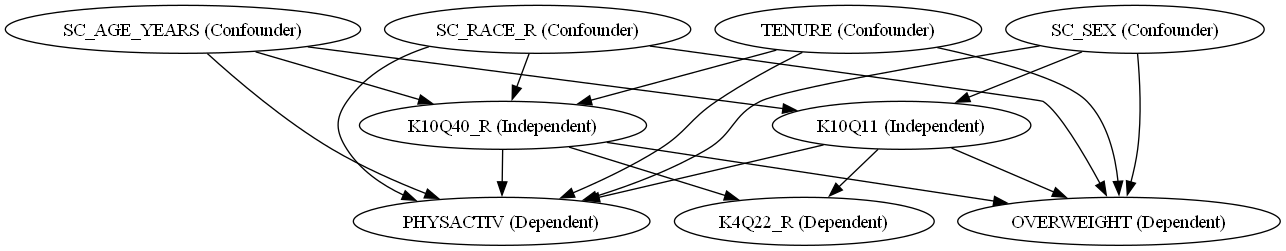

In [88]:
from IPython.display import Image

# Display the DAG diagram
Image(filename='dag_diagram.png')


In [89]:
pip install dowhy


^C
Note: you may need to restart the kernel to use updated packages.


C:\Users\rm130166\AppData\Local\Temp\ipykernel_18088\3739262979.py:6: DtypeWarning: Columns (88,121,394,397,400,403,406,447) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("NSCH_2021E_TOPICAL.csv")


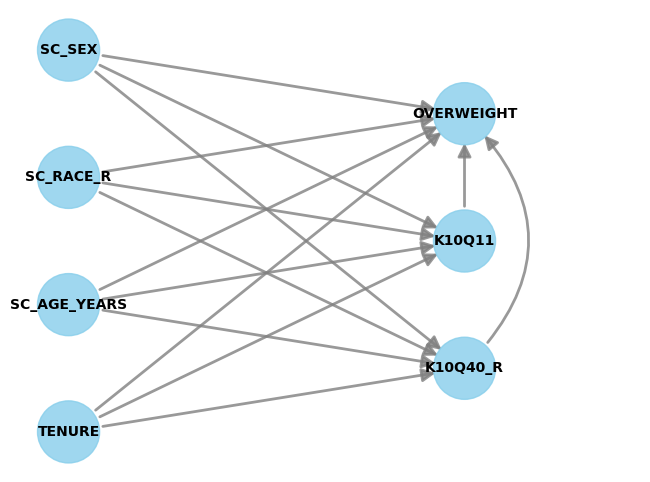

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                             
───────────────────(E[OVERWEIGHT|TENURE,SC_AGE_YEARS,SC_RACE_R,SC_SEX])
d[K10Q11  K10Q40_R]                                                    
Estimand assumption 1, Unconfoundedness: If U→{K10Q11,K10Q40_R} and U→OVERWEIGHT then P(OVERWEIGHT|K10Q11,K10Q40_R,TENURE,SC_AGE_YEARS,SC_RACE_R,SC_SEX,U) = P(OVERWEIGHT|K10Q11,K10Q40_R,TENURE,SC_AGE_YEARS,SC_RACE_R,SC_SEX)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [90]:
import dowhy
from dowhy import CausalModel
import pandas as pd

# Load your data
data = pd.read_csv("NSCH_2021E_TOPICAL.csv")

# Define the causal model
model = CausalModel(
    data=data,
    treatment=['K10Q11', 'K10Q40_R'],  # Independent variables
    outcome='OVERWEIGHT',              # Dependent variable
    common_causes=['SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS']  # Potential confounders
)

# View the model graphically
model.view_model()

# Check for confounding bias
identified_estimand = model.identify_effect()
print(identified_estimand)


In [91]:
# Check for NaN values in the selected columns
print(X.isnull().sum())

# Drop rows with NaN values (if needed)
X = X.dropna()

# Ensure all values are numeric
print(X.dtypes)


K10Q11          0
K10Q40_R        0
SC_SEX          0
SC_RACE_R       0
TENURE          0
SC_AGE_YEARS    0
dtype: int64
K10Q11          float64
K10Q40_R        float64
SC_SEX            int64
SC_RACE_R         int64
TENURE            int64
SC_AGE_YEARS      int64
dtype: object


In [92]:
# Check for unique values in these columns to identify any non-numeric entries
print(data['K10Q11'].unique())
print(data['K10Q40_R'].unique())


['1' '2' 'M']
['1' '3' '2' '4' 'M']


In [93]:
import numpy as np

# Replace 'M' with NaN
data['K10Q11'] = data['K10Q11'].replace('M', np.nan)
data['K10Q40_R'] = data['K10Q40_R'].replace('M', np.nan)


In [94]:
# Convert to numeric (after replacing 'M' with NaN)
data['K10Q11'] = pd.to_numeric(data['K10Q11'], errors='coerce')
data['K10Q40_R'] = pd.to_numeric(data['K10Q40_R'], errors='coerce')

# Verify conversion
print(data[['K10Q11', 'K10Q40_R']].dtypes)
print(data[['K10Q11', 'K10Q40_R']].isnull().sum())


K10Q11      float64
K10Q40_R    float64
dtype: object
K10Q11      1347
K10Q40_R    1601
dtype: int64


In [95]:
# Drop rows with NaN values in K10Q11 and K10Q40_R
data = data.dropna(subset=['K10Q11', 'K10Q40_R'])


In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare the data for VIF calculation
X = data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS']]

# Add a constant column
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


       Variable        VIF
0         const  29.274113
1        K10Q11   1.006413
2      K10Q40_R   1.029747
3        SC_SEX   1.000399
4     SC_RACE_R   1.016766
5        TENURE   1.031596
6  SC_AGE_YEARS   1.003365


In [97]:
print(data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS', 'OVERWEIGHT']].dtypes)


K10Q11          float64
K10Q40_R        float64
SC_SEX            int64
SC_RACE_R         int64
TENURE            int64
SC_AGE_YEARS      int64
OVERWEIGHT       object
dtype: object


In [98]:
print(data['OVERWEIGHT'].unique())


['2' '1' 'M']


In [99]:
data['OVERWEIGHT'] = pd.to_numeric(data['OVERWEIGHT'], errors='coerce')
print(data['OVERWEIGHT'].isnull().sum())  # Check for NaN values

# Option 1: Drop rows with NaN
data = data.dropna(subset=['OVERWEIGHT'])





C:\Users\rm130166\AppData\Local\Temp\ipykernel_18088\857305844.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['OVERWEIGHT'] = pd.to_numeric(data['OVERWEIGHT'], errors='coerce')


169


In [100]:
# Convert categorical overweight status (if 1=Yes, 2=No) to binary 0 and 1
data['OVERWEIGHT'] = data['OVERWEIGHT'].replace({1: 1, 2: 0})
# Check the unique values
print(data['OVERWEIGHT'].unique())



[0. 1.]


In [101]:
# Check data types of the independent and dependent variables
print(data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS', 'OVERWEIGHT']].dtypes)


K10Q11          float64
K10Q40_R        float64
SC_SEX            int64
SC_RACE_R         int64
TENURE            int64
SC_AGE_YEARS      int64
OVERWEIGHT      float64
dtype: object


In [102]:
import statsmodels.api as sm

# Prepare the data for logistic regression
X = data[['K10Q11', 'K10Q40_R', 'SC_SEX', 'SC_RACE_R', 'TENURE', 'SC_AGE_YEARS']]
y = data['OVERWEIGHT']

# Add a constant (intercept) to the model
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X).fit()

# Display the summary of the model
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.209751
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             OVERWEIGHT   No. Observations:                49001
Model:                          Logit   Df Residuals:                    48994
Method:                           MLE   Df Model:                            6
Date:                Sat, 12 Oct 2024   Pseudo R-squ.:                 0.07332
Time:                        16:43:52   Log-Likelihood:                -10278.
converged:                       True   LL-Null:                       -11091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -5.0388      0.110    -45.875      0.000      -5.254      -4.823
K10Q11           0.1553

In [103]:
# Calculate Odds Ratios (OR)
odds_ratios = np.exp(model.params)
print("\nOdds Ratios:\n", odds_ratios)

# Calculate 95% Confidence Intervals (CI)
conf = model.conf_int()
conf['OR'] = odds_ratios
conf.columns = ['2.5%', '97.5%', 'OR']

print("\n95% Confidence Intervals (CI) and OR:\n", conf)


Odds Ratios:
 const           0.006482
K10Q11          1.168015
K10Q40_R        1.384685
SC_SEX          0.892175
SC_RACE_R       1.020369
TENURE          1.272840
SC_AGE_YEARS    1.151542
dtype: float64

95% Confidence Intervals (CI) and OR:
                   2.5%     97.5%        OR
const        -5.254038 -4.823487  0.006482
K10Q11        0.070453  0.240158  1.168015
K10Q40_R      0.266784  0.384162  1.384685
SC_SEX       -0.190533 -0.037652  0.892175
SC_RACE_R    -0.000584  0.040912  1.020369
TENURE        0.197154  0.285347  1.272840
SC_AGE_YEARS  0.133229  0.148975  1.151542


In [104]:
# Calculate the proportion of overweight children for each level of K10Q40_R
proportion_overweight = data.groupby('K10Q40_R')['OVERWEIGHT'].mean()
print(proportion_overweight)


K10Q40_R
1.0    0.053237
2.0    0.071096
3.0    0.092229
4.0    0.126984
Name: OVERWEIGHT, dtype: float64
